In [1]:
import os
import time
import torch
import skimage
import sklearn.metrics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [2]:
import mnds
import extractor
import detection
import vision_transformer as vit

/scr/jcaicedo/anaconda3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
PATCH_SIZE = 256
STRIDE = 8
FEATURE_SIZE = 384
TOKENS_PER_PATCH = PATCH_SIZE // STRIDE
DIRECTORY = "."

BATCH_SIZE = 48
EPOCHS = 50
LR = 0.01

device = 'cuda:2' if torch.cuda.is_available() else 'cpu'

# Data loading and preparation

In [4]:
filelist = os.listdir(DIRECTORY)
annot_files = [x for x in filelist if x.endswith('png')]

training_files = annot_files[0:-1]
validation_files = [annot_files[-1]]

In [5]:
training_set = mnds.MicronucleiDataset(filelist=training_files, directory=DIRECTORY, mode="random", transform=mnds.detection_transforms)

100%|██████████████████████████████████████| 9/9 [00:20<00:00,  2.25s/it]


In [6]:
validation_set = mnds.MicronucleiDataset(filelist=validation_files, directory=DIRECTORY, mode="fixed")

100%|██████████████████████████████████████| 1/1 [00:03<00:00,  3.71s/it]

20X_c0-DAPI_A1_Tile-130: Micronuclei at (695,2842) is not covered by any patches
20X_c0-DAPI_A1_Tile-130: Micronuclei at (1371,2922) is not covered by any patches
20X_c0-DAPI_A1_Tile-130: Micronuclei at (2847,1975) is not covered by any patches
20X_c0-DAPI_A1_Tile-130: Micronuclei at (2870,795) is not covered by any patches


In [7]:
len(training_set)

1089

In [8]:
training_set.all_locs.groupby("Image").count()

,x,y
Image,,
./20X_c0-DAPI_A1_Tile-10.phenotype.tif,6,6
./20X_c0-DAPI_A1_Tile-110.phenotype.tif,36,36
./20X_c0-DAPI_A1_Tile-150.phenotype.tif,34,34
./20X_c0-DAPI_A1_Tile-170.phenotype.tif,97,97
./20X_c0-DAPI_A1_Tile-190.phenotype.tif,47,47
./20X_c0-DAPI_A1_Tile-30.phenotype.tif,36,36
./20X_c0-DAPI_A1_Tile-50.phenotype.tif,115,115
./20X_c0-DAPI_A1_Tile-70.phenotype.tif,47,47
./20X_c0-DAPI_A1_Tile-90.phenotype.tif,82,82


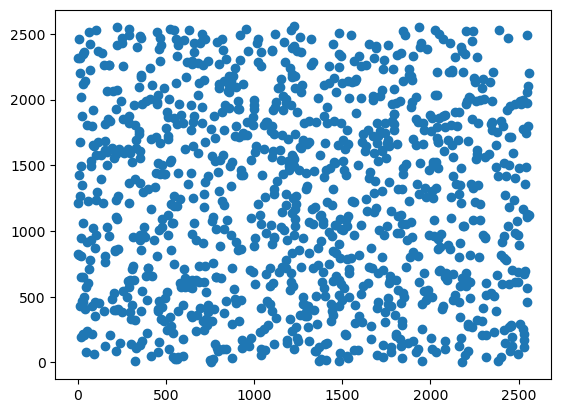

In [9]:
data = np.array([k["coord"] for k in training_set.index])
plt.scatter(data[:,0], data[:,1])

2816 2816 torch.Size([3, 256, 256]) torch.Size([32, 32])


(-0.5, 255.5, 255.5, -0.5)

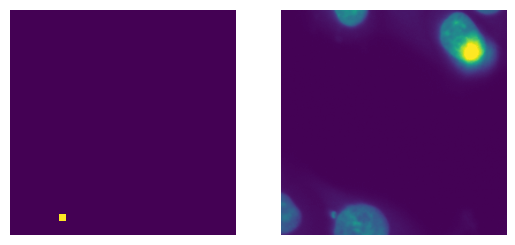

In [10]:
im, lbl = training_set[4]
print(training_set.W, training_set.H, im.shape, lbl.shape)

fig, ax = plt.subplots(1,2)
ax[0].imshow(lbl)
ax[0].axis('off')
ax[1].imshow(im[0,...])
ax[1].axis('off')

In [11]:
train_dataloader = DataLoader(training_set, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(validation_set, batch_size=4, shuffle=False)

# Model and training loop

In [12]:
model = detection.DetectionModel(device=device)
model

Using cache found in /home/caicedo/.cache/torch/hub/facebookresearch_dino_main


DetectionModel(
  (vit_model): TruncViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(384, 192, kernel_size=(1, 1), stride=(1, 1))
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=192, out_features=576, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=192, out_features=192, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (drop_path): Identity()
        (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=192, out_features=768, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=768, out_features=192, bias=True)
          (drop): Dropout(p=0.0, inplace=False)
        )
      )
    )
    (norm): LayerNorm((192

In [13]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=0.9)

In [14]:
def train_one_epoch(epoch_index, tb_writer):
    running_loss = 0.
    last_loss = 0.
    
    train_dataloader.dataset.randomize_patch_index()
    for i, data in enumerate(train_dataloader):
        x, y = data
        optimizer.zero_grad()
        p = model(x.to(device))
        
        # Loss function
        Y = torch.reshape(y, (-1, 32*32)).to(device)
        loss = loss_fn(p, Y)
        
        # Training instructions
        loss.backward()
        optimizer.step()
        
        # Report results
        running_loss += loss.item()
#         if i % 10 == 9:
#             last_loss = running_loss / 10
#             print(f' batch {i} loss: {last_loss}')
#             running_loss = 0
    return running_loss / i

In [20]:
best_vloss = 1_000_000.
epoch_number = 0

start = time.time()
for epoch in range(EPOCHS):
    # Training
    print(f'EPOCH {epoch} - ', end='')
    T = time.time()
    model.train(True)
    avg_loss = train_one_epoch(epoch_number, None)
    
    # Validation
    running_vloss = 0.0
    model.eval()
    with torch.no_grad():
        for i, vdata in enumerate(val_dataloader):
            vin, vls = vdata
            vout = model(vin.to(device))
            Y = torch.reshape(vls, (-1, 32*32)).to(device)
            vloss = loss_fn(vout, Y)
            running_vloss += vloss
    avg_vloss = running_vloss / (i+1)
    C = time.time() - T
    print(f'LOSS: Training: {avg_loss} - Validation: {avg_vloss} - Time: {C:.2f} secs')
    
    epoch_number += 1

C = time.time() - start
print(f"\nTrainined finished in {C:.2f} seconds")

EPOCH 0 - LOSS: Training: 4.390480334108526 - Validation: 6.300364636605786 - Time: 35.52 secs
EPOCH 1 - LOSS: Training: 4.26460494778373 - Validation: 6.306054122986332 - Time: 35.75 secs
EPOCH 2 - LOSS: Training: 4.149394078688188 - Validation: 6.295436270775333 - Time: 35.82 secs
EPOCH 3 - LOSS: Training: 4.512013998898593 - Validation: 6.29036206968369 - Time: 35.85 secs
EPOCH 4 - LOSS: Training: 4.160753764889457 - Validation: 6.310652413675862 - Time: 36.02 secs
EPOCH 5 - LOSS: Training: 4.281950202855197 - Validation: 6.2843384781191425 - Time: 35.94 secs
EPOCH 6 - LOSS: Training: 4.034789443016052 - Validation: 6.278330810608402 - Time: 35.86 secs
EPOCH 7 - LOSS: Training: 4.404352480714971 - Validation: 6.277954893727456 - Time: 35.87 secs
EPOCH 8 - LOSS: Training: 4.321451349691912 - Validation: 6.263704899818666 - Time: 35.80 secs
EPOCH 9 - LOSS: Training: 4.270484230735085 - Validation: 6.263480324898996 - Time: 35.79 secs
EPOCH 10 - LOSS: Training: 4.0282346552068535 - Val

# Validation metrics

In [21]:
def display_examples(vin, vls, pred):
    for j in range(pred.shape[0]):
        # Visualize predictions
        fig, ax = plt.subplots(1,4)

        ax[0].imshow(pred[j] )
        ax[0].axis('off')

        ax[1].imshow(pred[j] > 0.2)
        ax[1].axis('off')

        ax[2].imshow(vls[j])
        ax[2].axis('off')

        ax[3].imshow(vin[j][0,...])
        ax[3].axis('off')
        plt.show()

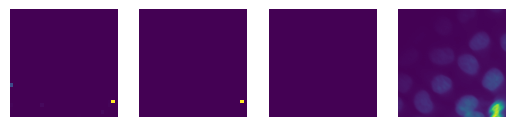

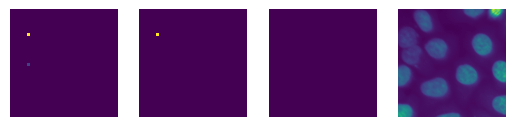

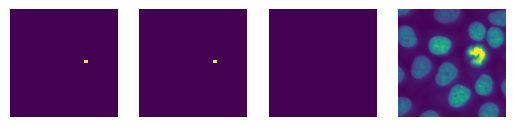

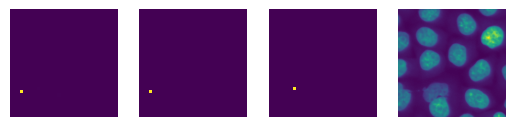

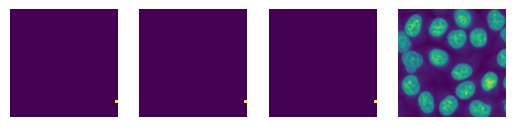

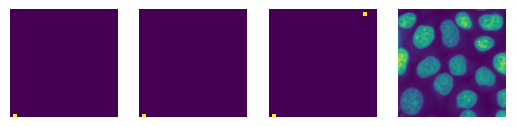

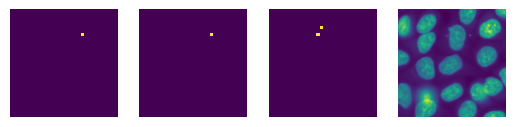

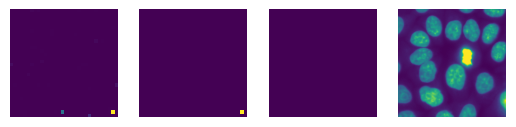

In [22]:
model.eval()

GT = []
PRED = []

with torch.no_grad():
    for i, vdata in enumerate(val_dataloader):
        # Get predictions
        vin, vls = vdata
        pred0 = model(vin.to(device))
        P = torch.reshape(pred0, (-1, 32, 32))
        pred = P.cpu().numpy()
        
        # Collect predictions and ground truth
        PRED.append(pred)
        GT.append(vls.cpu().numpy())
        
        if i % 20 == 0: 
            display_examples(vin, vls, pred)
            
PRED = np.concatenate(PRED, axis=0).reshape((-1,))
GT = np.concatenate(GT, axis=0).reshape((-1,))

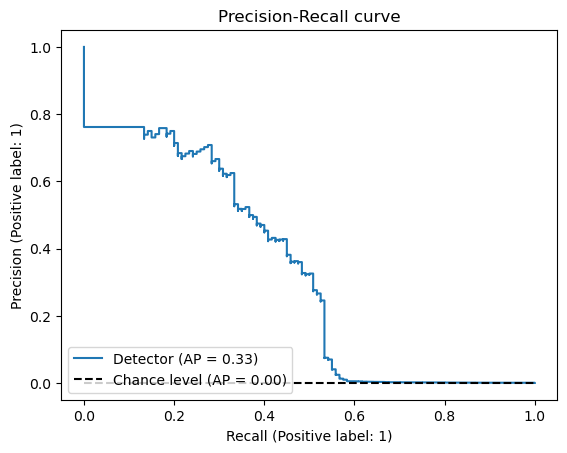

In [23]:
# Precision-recall curve
display = sklearn.metrics.PrecisionRecallDisplay.from_predictions(
    GT, PRED, name="Detector", plot_chance_level=True
)
_ = display.ax_.set_title("Precision-Recall curve")

In [26]:
# Classification report
report = sklearn.metrics.classification_report(GT, PRED > 0.5)
print(report)

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    123784
         1.0       0.45      0.41      0.43       120

    accuracy                           1.00    123904
   macro avg       0.72      0.70      0.71    123904
weighted avg       1.00      1.00      1.00    123904

